Revisión metodológica / Method review: ver ../DECISION_REVIEW.md. Cierres hasta 2035; cohortes no equivalen a ventas de dos años. Compras no equivalen a demanda. Ahorros y políticas requieren validación.

# Market Stall — Metrics, Statistics & Supply-Based Sales Analysis

**About this project.** This is a portfolio piece. The original project was built in **Spanish** for a
real family market-stall (*feria*) business; this notebook is a full **adaptation and translation** to
English. All **supplier names, contacts and locations are fictitious**, and all **monetary amounts are
approximate** — grounded in real reference ranges from Chilean fairs and wholesale suppliers (2025-2026),
but illustrative rather than actual quotes. Amounts are shown in **CLP and USD** (1 USD = 935 CLP,
observed 21 Jul 2026).

**What this notebook does.** It identifies the most useful metrics and statistics for this kind of
business and runs a **supply-based sales analysis**: instead of a line-by-line sales log (unrealistic at a
fast fair), sales are measured through **purchase batches** and how each batch was closed (fully sold vs.
partial loss). The data spans **two years** with realistic seasonality, summer-heat spoilage, holiday
demand bumps and a mild year-over-year growth trend.

**Sections**
1. Setup (installs libraries automatically)
2. Load & prepare data
3. Catalog overview
4. Profitability & margins
5. 2-year sales & waste (the supply-based core)
6. Seasonality & demand
7. Inventory: ABC & stock health
8. Supply chain: dependency, backup coverage, supplier performance
9. Inferential statistics
10. Export analysis-ready data
11. Business case: freezer ROI
12. Inventory optimization: EOQ, reorder point & safety stock
13. Demand forecasting


## 1. Setup — install & import libraries

This cell installs everything the notebook needs, so it runs end-to-end without any manual setup.


In [1]:
import sys, subprocess

def ensure(pkgs):
    for p in pkgs:
        mod = p.split("==")[0]
        try:
            __import__(mod)
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", p])

ensure(["pandas", "numpy", "matplotlib", "seaborn", "scipy", "statsmodels"])
print("All libraries ready.")


All libraries ready.


In [2]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10
PALETTE = ["#1F4E5F", "#B5651D", "#548235", "#8FAADC", "#C00000", "#7F7F7F"]
sns.set_palette(PALETTE)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
USD_RATE = 935.0


## 2. Load & prepare data

In [3]:
products   = pd.read_csv("data/products.csv", encoding="utf-8-sig")
suppliers  = pd.read_csv("data/suppliers.csv", encoding="utf-8-sig")
links      = pd.read_csv("data/supply_links.csv", encoding="utf-8-sig")
purchases  = pd.read_csv("data/purchases.csv", encoding="utf-8-sig")
outcomes   = pd.read_csv("data/batch_outcomes.csv", encoding="utf-8-sig")

for df_ in (purchases,):
    df_["PurchaseDate"] = pd.to_datetime(df_["PurchaseDate"])
    df_["ExpiryDate"] = pd.to_datetime(df_["ExpiryDate"])

print("products", products.shape, "| suppliers", suppliers.shape, "| links", links.shape)
print("purchases", purchases.shape, "| outcomes", outcomes.shape)
products.head(3)


products (128, 10) | suppliers (22, 7) | links (256, 13)
purchases (3825, 16) | outcomes (3825, 14)


,ProductID,Product,Category,SaleUnit,PriceType,Essential,PeakSeason,SalePrice_CLP,SalePrice_USD,CurrentStock
0,P001,"Olives 120/140 (extra large), brined",Olives,kg,By Weight (kg),Yes,Spring-Summer,4000,4.28,High
1,P002,"Olives 140/160 (large), brined",Olives,kg,By Weight (kg),Yes,Spring-Summer,3500,3.74,Low
2,P003,"Olives 160/180, brined",Olives,kg,By Weight (kg),Yes,Spring-Summer,3500,3.74,Medium


In [4]:
# Product-level margin from the PRIMARY supplier
primary = links[links["SupplierRole"]=="Primary"][["ProductID","PurchasePrice_CLP","SupplierName","LeadTime_Days"]]
prod = products.merge(primary, on="ProductID", how="left")
prod["Margin_CLP"] = prod["SalePrice_CLP"] - prod["PurchasePrice_CLP"]
prod["Margin_Pct"] = prod["Margin_CLP"] / prod["SalePrice_CLP"]

# Batch-level analysis frame: purchases + outcomes + product attributes
batches = purchases.merge(
    outcomes[["BatchID","Status","QtySold","QtyWasted","WastedPct","Revenue_CLP","Revenue_USD","GrossProfit_CLP","GrossProfit_USD"]],
    on="BatchID", how="left"
).merge(products[["ProductID","Essential","PeakSeason","PriceType"]], on="ProductID", how="left")
batches["YearMonth"] = batches["PurchaseDate"].dt.to_period("M").astype(str)
batches["Year"] = batches["PurchaseDate"].dt.year
print("Analysis frame:", batches.shape)
batches[["BatchID","Product","Category","PurchaseDate","Quantity","Status","WastedPct","Revenue_USD"]].head(4)


Analysis frame: (3825, 29)


,BatchID,Product,Category,PurchaseDate,Quantity,Status,WastedPct,Revenue_USD
0,B00001,"Olives 120/140 (extra large), brined",Olives,2023-07-09,16,Partial Loss,26.4,50.40
1,B00002,"Olives 120/140 (extra large), brined",Olives,2023-07-20,13,Partial Loss,10.5,49.75
2,B00003,"Olives 120/140 (extra large), brined",Olives,2023-07-29,13,Partial Loss,10.5,49.75
3,B00004,"Olives 120/140 (extra large), brined",Olives,2023-08-05,16,Sold Out,0.0,68.45


## 3. Catalog overview

A quick sense of the catalog's size and shape. The **coefficient of variation** (std / mean) lets us
compare price dispersion fairly across categories with very different price levels.


In [5]:
overview = prod.groupby("Category").agg(
    n_products=("ProductID","count"),
    avg_price=("SalePrice_CLP","mean"),
    price_std=("SalePrice_CLP","std"),
    n_essential=("Essential", lambda s: (s=="Yes").sum()),
).round(0)
overview["coef_variation"] = (overview["price_std"]/overview["avg_price"]).round(2)
overview = overview.sort_values("n_products", ascending=False)
overview


,n_products,avg_price,price_std,n_essential,coef_variation
Category,,,,,
Candy,17,1088.0,712.0,0,0.65
Packaging,17,3059.0,1310.0,0,0.43
Nuts,15,17367.0,8346.0,1,0.48
Dried Fruit,12,6458.0,1356.0,2,0.21
Olives,11,3227.0,410.0,4,0.13
Seasonings,11,1500.0,316.0,2,0.21
Chili,9,1889.0,220.0,2,0.12
Peanuts,9,7944.0,1810.0,1,0.23
Pickles,5,2800.0,274.0,0,0.10


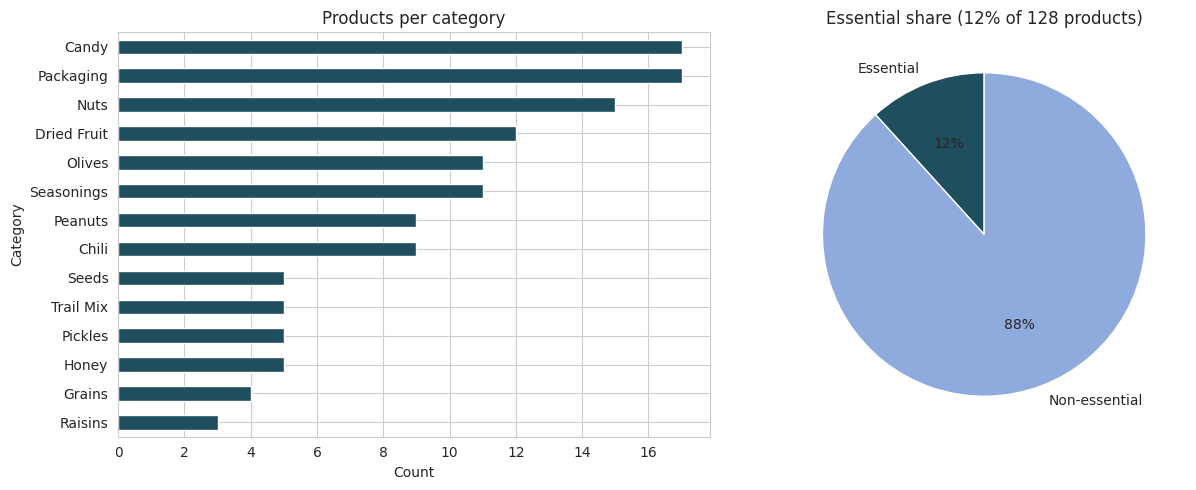

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
overview["n_products"].sort_values().plot(kind="barh", ax=axes[0], color=PALETTE[0])
axes[0].set_title("Products per category"); axes[0].set_xlabel("Count")
ess = (prod["Essential"]=="Yes").sum(); non = (prod["Essential"]=="No").sum()
axes[1].pie([ess,non], labels=["Essential","Non-essential"], autopct="%1.0f%%",
            colors=[PALETTE[0],PALETTE[3]], startangle=90)
axes[1].set_title(f"Essential share ({ess/len(prod)*100:.0f}% of {len(prod)} products)")
plt.tight_layout(); plt.show()


## 4. Profitability & margins

Margin percentage is the single most useful profitability metric here because it compares fairly across a
$0.50 candy bag and a $30 bag of pistachios.


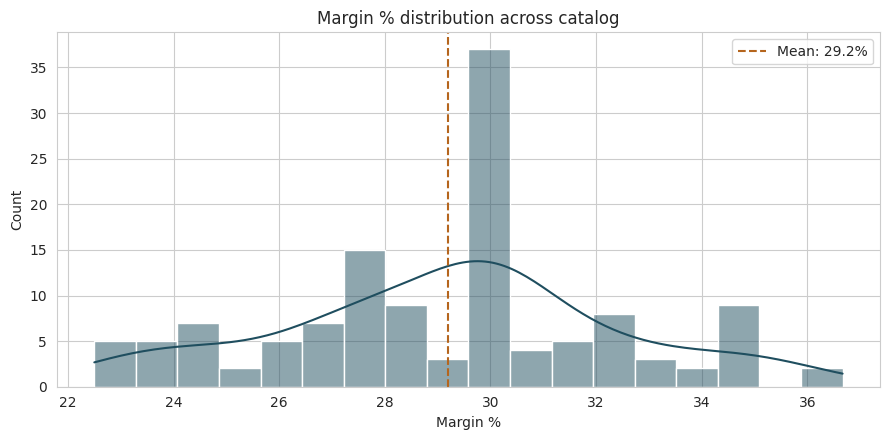

count    128.000
mean       0.292
std        0.032
min        0.225
25%        0.274
50%        0.300
75%        0.306
max        0.367


In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(prod["Margin_Pct"]*100, bins=18, kde=True, color=PALETTE[0], ax=ax)
ax.axvline(prod["Margin_Pct"].mean()*100, color=PALETTE[1], linestyle="--",
           label=f"Mean: {prod['Margin_Pct'].mean()*100:.1f}%")
ax.set_title("Margin % distribution across catalog"); ax.set_xlabel("Margin %"); ax.legend()
plt.tight_layout(); plt.show()
print(prod["Margin_Pct"].describe().round(3).to_string())


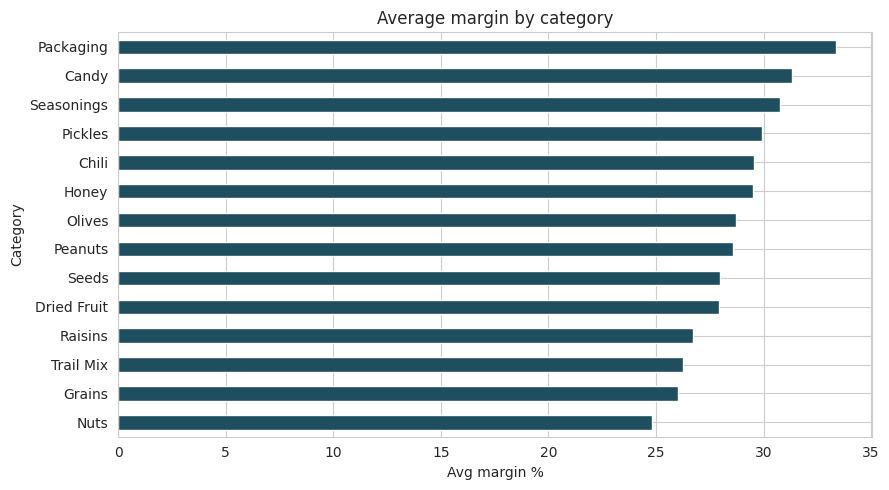

In [8]:
margin_cat = (prod.groupby("Category")["Margin_Pct"].mean()*100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
margin_cat.plot(kind="barh", ax=ax, color=PALETTE[0]); ax.invert_yaxis()
ax.set_xlabel("Avg margin %"); ax.set_title("Average margin by category")
plt.tight_layout(); plt.show()


In [9]:
top10 = prod.nlargest(10, "Margin_Pct")[["Product","Category","SalePrice_CLP","Margin_Pct"]].copy()
top10["Margin_Pct"] = (top10["Margin_Pct"]*100).round(1)
print("Top 10 products by margin %:"); display(top10.reset_index(drop=True))


Top 10 products by margin %:


,Product,Category,SalePrice_CLP,Margin_Pct
0,Poly bag 12x20cm (pack of 100),Packaging,1500,36.7
1,Poly bag 30x40cm (pack of 100),Packaging,4000,36.2
2,"Bay leaves, bag 50g",Seasonings,1000,35.0
3,Gummy candy bag 100g,Candy,1000,35.0
4,Toffee caramels bag 100g,Candy,1000,35.0
5,Licorice bag 100g,Candy,1000,35.0
6,Coconut candy bag 100g,Candy,1000,35.0
7,Poly bag 10x15cm (pack of 100),Packaging,1000,35.0
8,Poly bag 15x25cm (pack of 100),Packaging,2000,35.0
9,Poly bag 25x35cm (pack of 100),Packaging,3000,35.0


## 5. Two-year sales & waste  — the supply-based core

This is where purchasing becomes a sales analysis. Each batch is closed as **Sold Out** or **Partial
Loss (x%)**, which gives revenue, gross profit and waste over time — without a per-sale log.


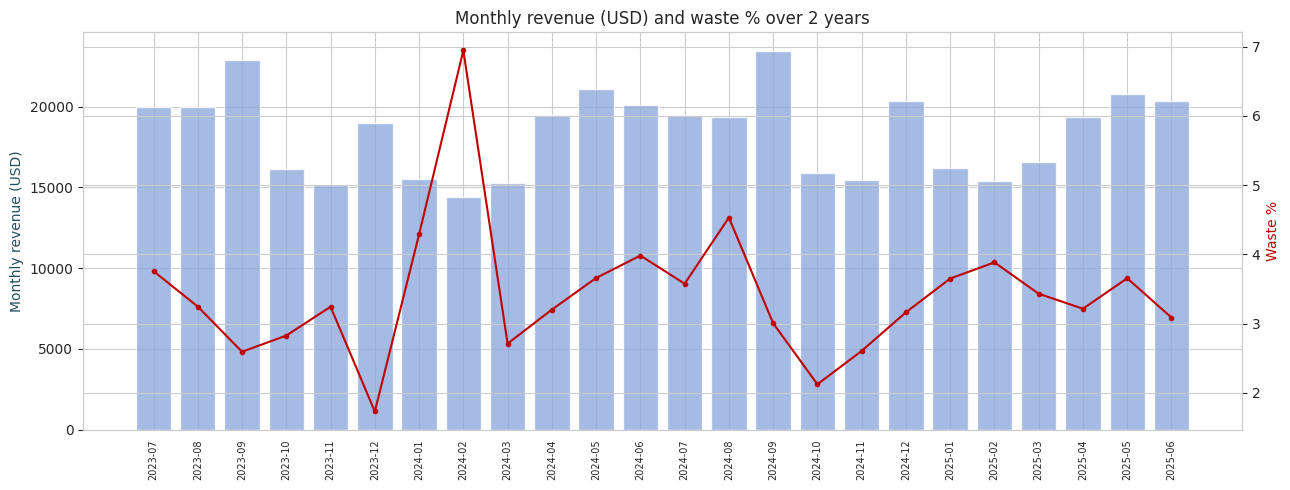

Total 2Y revenue: US$ 441,633
Total 2Y gross profit: US$ 110,556
Overall waste rate: 3.4%


In [10]:
monthly = batches.groupby("YearMonth").agg(
    Revenue_CLP=("Revenue_CLP","sum"),
    GrossProfit_CLP=("GrossProfit_CLP","sum"),
    QtyPurchased=("Quantity","sum"),
    QtyWasted=("QtyWasted","sum"),
).reset_index()
monthly["Revenue_USD"] = monthly["Revenue_CLP"]/USD_RATE
monthly["WastePct"] = monthly["QtyWasted"]/monthly["QtyPurchased"]*100

fig, ax1 = plt.subplots(figsize=(13, 5))
x = range(len(monthly))
ax1.bar(x, monthly["Revenue_USD"], color=PALETTE[3], alpha=0.8, label="Revenue (USD)")
ax1.set_ylabel("Monthly revenue (USD)", color=PALETTE[0])
ax1.set_xticks(list(x)); ax1.set_xticklabels(monthly["YearMonth"], rotation=90, fontsize=7)
ax2 = ax1.twinx()
ax2.plot(x, monthly["WastePct"], color=PALETTE[4], marker="o", markersize=3, label="Waste %")
ax2.set_ylabel("Waste %", color=PALETTE[4])
ax1.set_title("Monthly revenue (USD) and waste % over 2 years")
plt.tight_layout(); plt.show()

print(f"Total 2Y revenue: US$ {monthly['Revenue_USD'].sum():,.0f}")
print(f"Total 2Y gross profit: US$ {batches['GrossProfit_USD'].sum():,.0f}")
print(f"Overall waste rate: {batches['QtyWasted'].sum()/batches['Quantity'].sum()*100:.1f}%")


In [11]:
# Year-over-year growth (business is modernizing)
yoy = batches.groupby("Year").agg(Revenue_CLP=("Revenue_CLP","sum"),
                                   GrossProfit_CLP=("GrossProfit_CLP","sum")).reset_index()
yoy["Revenue_USD"] = (yoy["Revenue_CLP"]/USD_RATE).round(0)
# note: 2023 and 2025 are partial years (Jul-Dec 2023, Jan-Jun 2025); 2024 is the only full year
print("Revenue by calendar year (2023 & 2025 are half-years):")
display(yoy[["Year","Revenue_USD"]])


Revenue by calendar year (2023 & 2025 are half-years):


,Year,Revenue_USD
0,2023,113061.0
1,2024,219951.0
2,2025,108622.0


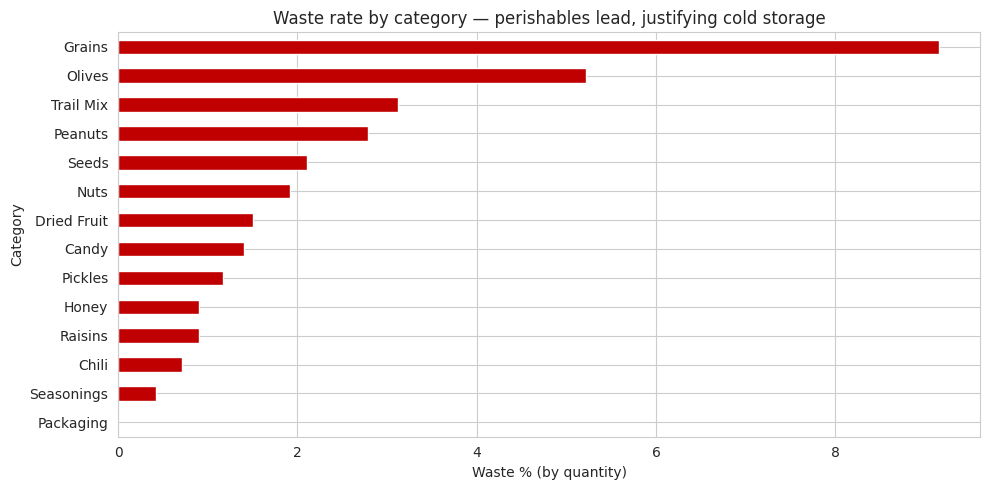

,waste_pct,lost_revenue_usd
Category,,
Grains,9.2,2462.2
Olives,5.2,4454.1
Trail Mix,3.1,551.3
Peanuts,2.8,1711.9
Seeds,2.1,114.4
Nuts,1.9,2726.7
Dried Fruit,1.5,464.4
Candy,1.4,253.8
Pickles,1.2,94.8


In [12]:
# Waste by category — where the money is actually lost
waste_cat = batches.groupby("Category").apply(
    lambda g: pd.Series({
        "waste_pct": g["QtyWasted"].sum()/g["Quantity"].sum()*100,
        "lost_revenue_usd": (g["QtyWasted"] * g.merge(products[["ProductID","SalePrice_CLP"]], on="ProductID")["SalePrice_CLP"].values / USD_RATE).sum()
    }), include_groups=False
).sort_values("waste_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
waste_cat["waste_pct"].plot(kind="barh", ax=ax, color=PALETTE[4]); ax.invert_yaxis()
ax.set_xlabel("Waste % (by quantity)")
ax.set_title("Waste rate by category — perishables lead, justifying cold storage")
plt.tight_layout(); plt.show()
display(waste_cat.round(1))


The waste breakdown is the analytical backbone of the business case for a chest freezer: the perishable
categories (grains/cooked mote, olives) concentrate the losses, and they spike in summer months — exactly
the pattern the freezer investment targets.


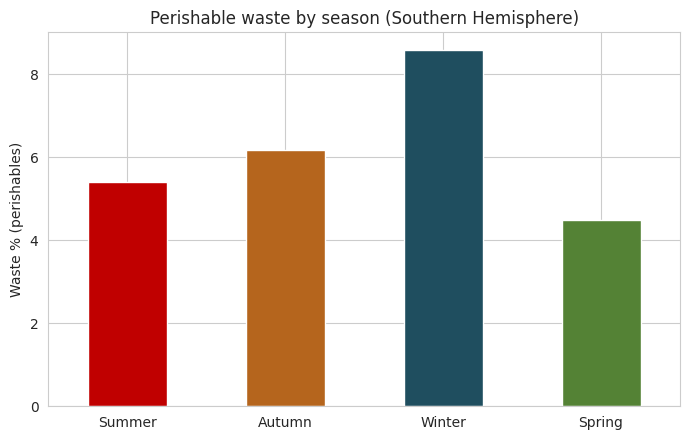

SeasonSH
Summer    5.4
Autumn    6.2
Winter    8.6
Spring    4.5


In [13]:
# Seasonal waste: is summer really worse for perishables?
batches["MonthNum"] = batches["PurchaseDate"].dt.month
season_map = {12:"Summer",1:"Summer",2:"Summer",3:"Autumn",4:"Autumn",5:"Autumn",
              6:"Winter",7:"Winter",8:"Winter",9:"Spring",10:"Spring",11:"Spring"}
batches["SeasonSH"] = batches["MonthNum"].map(season_map)
perish = batches[batches["Category"].isin(["Olives","Grains","Peanuts","Honey","Trail Mix"])]
sw = perish.groupby("SeasonSH").apply(lambda g: g["QtyWasted"].sum()/g["Quantity"].sum()*100, include_groups=False).reindex(["Summer","Autumn","Winter","Spring"])
fig, ax = plt.subplots(figsize=(7, 4.5))
sw.plot(kind="bar", ax=ax, color=[PALETTE[4],PALETTE[1],PALETTE[0],PALETTE[2]])
ax.set_ylabel("Waste % (perishables)"); ax.set_title("Perishable waste by season (Southern Hemisphere)")
ax.set_xlabel(""); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()
print(sw.round(1).to_string())


## 6. Seasonality & demand

Seasonal demand measured from actual purchase volumes (we buy more when we expect to sell more).


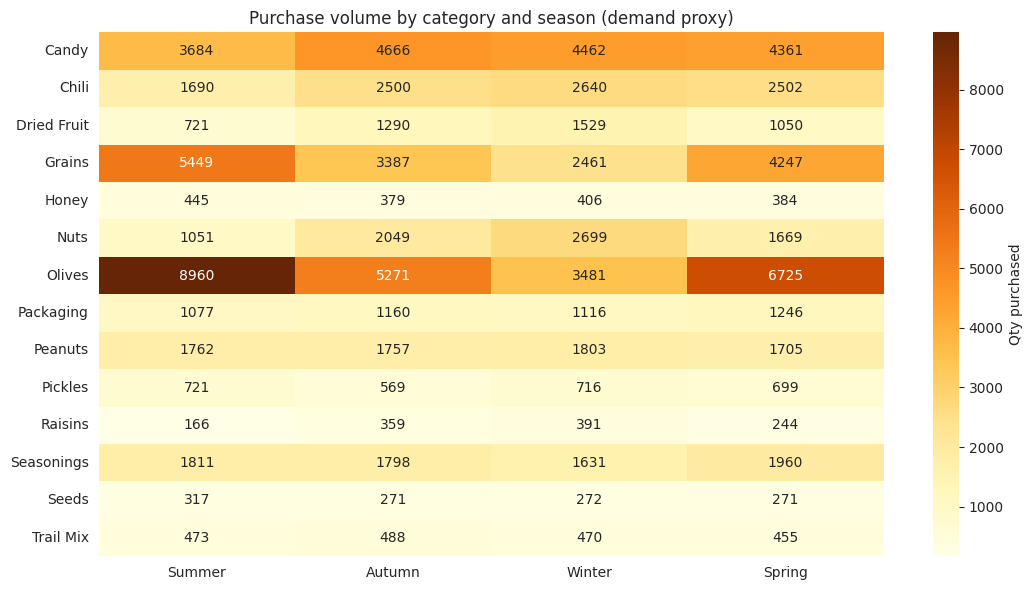

In [14]:
cat_season = batches.groupby(["Category","SeasonSH"])["Quantity"].sum().unstack().fillna(0)
cat_season = cat_season[["Summer","Autumn","Winter","Spring"]]
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(cat_season, annot=True, fmt=".0f", cmap="YlOrBr", ax=ax, cbar_kws={"label":"Qty purchased"})
ax.set_title("Purchase volume by category and season (demand proxy)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()


## 7. Inventory: ABC classification & stock health

Now with real revenue we can build a **proper ABC classification** based on 2-year revenue contribution
(the classic Pareto approach), not a proxy.


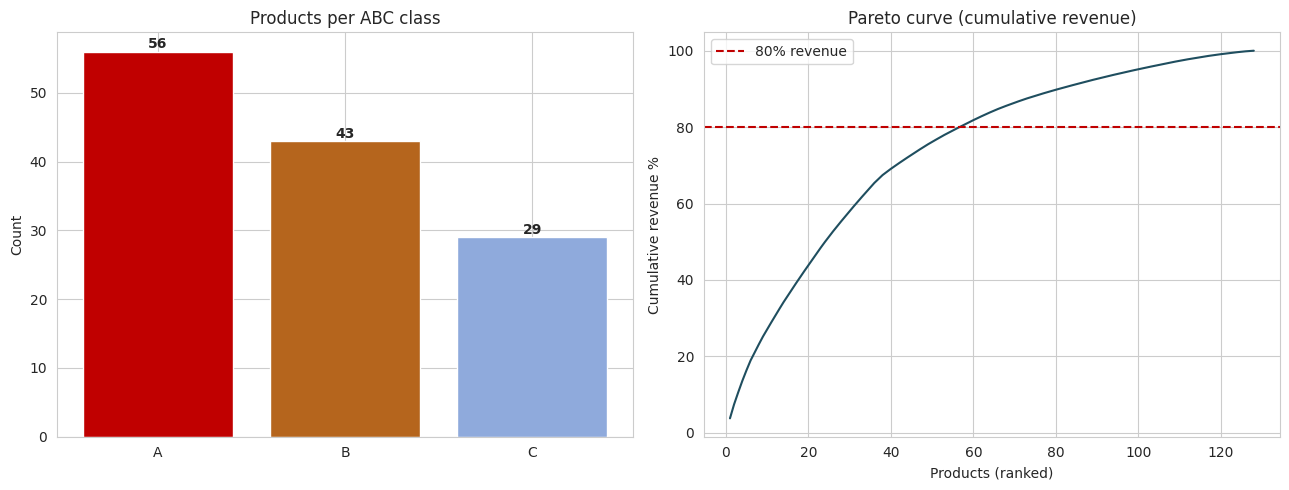

Class A: 56 products (44% of catalog) drive 80% of revenue.


In [15]:
rev_by_prod = batches.groupby("ProductID")["Revenue_CLP"].sum().sort_values(ascending=False)
abc = rev_by_prod.to_frame("Revenue_CLP")
abc["cum_pct"] = abc["Revenue_CLP"].cumsum()/abc["Revenue_CLP"].sum()*100
abc["Class"] = np.where(abc["cum_pct"]<=80, "A", np.where(abc["cum_pct"]<=95, "B", "C"))
prod = prod.merge(abc[["Class"]], left_on="ProductID", right_index=True, how="left")

counts = abc["Class"].value_counts().reindex(["A","B","C"])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(counts.index, counts.values, color=[PALETTE[4],PALETTE[1],PALETTE[3]])
for i,v in enumerate(counts.values): axes[0].text(i, v+0.5, str(v), ha="center", fontweight="bold")
axes[0].set_title("Products per ABC class"); axes[0].set_ylabel("Count")
# Pareto curve
axes[1].plot(range(1,len(abc)+1), abc["cum_pct"].values, color=PALETTE[0])
axes[1].axhline(80, color=PALETTE[4], linestyle="--", label="80% revenue")
axes[1].set_title("Pareto curve (cumulative revenue)"); axes[1].set_xlabel("Products (ranked)")
axes[1].set_ylabel("Cumulative revenue %"); axes[1].legend()
plt.tight_layout(); plt.show()
a_n = (abc['Class']=='A').sum()
print(f"Class A: {a_n} products ({a_n/len(abc)*100:.0f}% of catalog) drive 80% of revenue.")


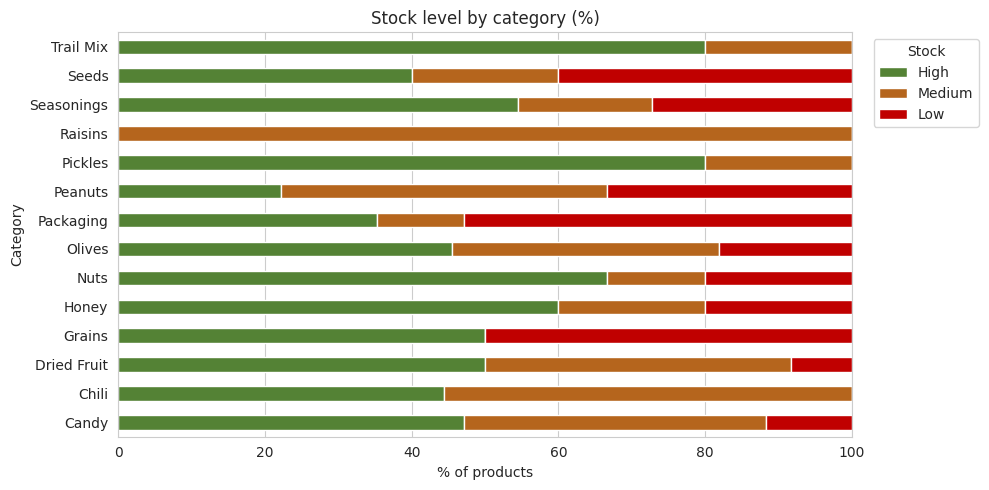

In [16]:
stock_cat = pd.crosstab(prod["Category"], prod["CurrentStock"])[["High","Medium","Low"]]
stock_pct = stock_cat.div(stock_cat.sum(axis=1), axis=0)*100
fig, ax = plt.subplots(figsize=(10, 5))
stock_pct.plot(kind="barh", stacked=True, ax=ax, color=[PALETTE[2],PALETTE[1],PALETTE[4]])
ax.set_xlabel("% of products"); ax.set_title("Stock level by category (%)")
ax.legend(title="Stock", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()


## 8. Supply chain: dependency, backup coverage & performance

The supply advice centers on two things: **every product has a documented backup supplier**, and the
**Herfindahl-Hirschman Index (HHI)** quantifies how concentrated the supplier base is.

$$HHI = \sum_i (s_i \times 100)^2 \quad (<1500\text{ low},\ 1500\text{-}2500\text{ moderate},\ >2500\text{ high})$$


In [17]:
scorecard = links[links["SupplierRole"]=="Primary"].groupby("SupplierName").agg(
    n_products=("ProductID","count"),
    avg_lead=("LeadTime_Days","mean"),
).round(2)
ess_map = products.set_index("ProductID")["Essential"].eq("Yes")
prim = links[links["SupplierRole"]=="Primary"].copy()
prim["is_ess"] = prim["ProductID"].map(ess_map)
scorecard["n_essential"] = prim.groupby("SupplierName")["is_ess"].sum()
scorecard = scorecard.sort_values("n_products", ascending=False)

shares = scorecard["n_products"]/scorecard["n_products"].sum()*100
hhi = (shares**2).sum()
level = "low" if hhi<1500 else ("moderate" if hhi<2500 else "high")
print(f"Supplier HHI: {hhi:.0f} / 10000  ->  {level} concentration")
print(f"Backup coverage: {(links['SupplierRole']=='Backup').sum()}/{len(products)} products have a documented backup ({(links['SupplierRole']=='Backup').sum()/len(products)*100:.0f}%)")
display(scorecard)


Supplier HHI: 1433 / 10000  ->  low concentration
Backup coverage: 128/128 products have a documented backup (100%)


,n_products,avg_lead,n_essential
SupplierName,,,
Maipo Nuts Ltd.,34,1.62,2
Molina Artisan Sweets,17,2.18,0
PackChile Wholesale,17,1.41,0
San Fernando Dried Goods,15,1.60,3
Valley Spices SpA,11,1.64,2
El Olivar Olives Ltd.,11,2.18,4
Curico Chili & Sauces,9,1.67,2
Doña Rosa Pickles,5,2.20,0
Los Ulmos Apiary,5,2.20,1


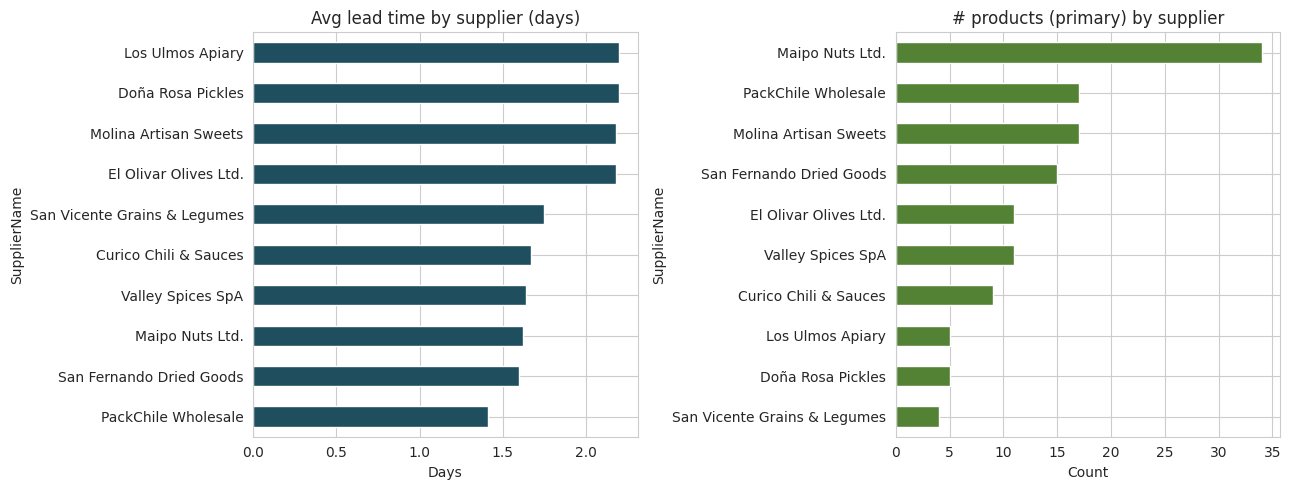

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scorecard["avg_lead"].sort_values().plot(kind="barh", ax=axes[0], color=PALETTE[0])
axes[0].set_title("Avg lead time by supplier (days)"); axes[0].set_xlabel("Days")
scorecard["n_products"].sort_values().plot(kind="barh", ax=axes[1], color=PALETTE[2])
axes[1].set_title("# products (primary) by supplier"); axes[1].set_xlabel("Count")
plt.tight_layout(); plt.show()


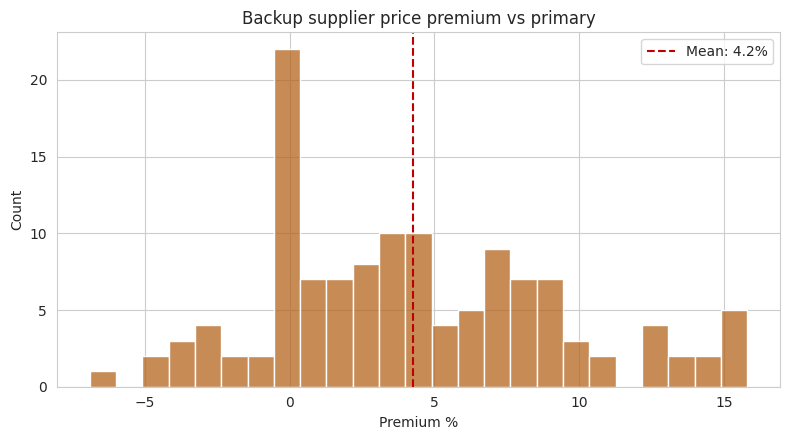

On average the backup supplier costs 4.2% more — the price of resilience.


In [19]:
# Primary vs backup: how much more expensive is the fallback?
cmp = links.pivot_table(index="ProductID", columns="SupplierRole", values="PurchasePrice_CLP")
cmp["backup_premium_pct"] = (cmp["Backup"]-cmp["Primary"])/cmp["Primary"]*100
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(cmp["backup_premium_pct"], bins=25, color=PALETTE[1], ax=ax)
ax.axvline(cmp["backup_premium_pct"].mean(), color=PALETTE[4], linestyle="--",
           label=f"Mean: {cmp['backup_premium_pct'].mean():.1f}%")
ax.set_title("Backup supplier price premium vs primary"); ax.set_xlabel("Premium %"); ax.legend()
plt.tight_layout(); plt.show()
print(f"On average the backup supplier costs {cmp['backup_premium_pct'].mean():.1f}% more — the price of resilience.")


## 9. Inferential statistics

**Question:** do batches from the *backup* supplier end in partial loss more often than *primary*-supplier
batches? We use a chi-square test of independence between supplier role and batch outcome.


In [20]:
ct = pd.crosstab(batches["SupplierRole"], batches["Status"])
chi2, p, dof, exp = stats.chi2_contingency(ct)
print("Contingency table (role x outcome):"); display(ct)
print(f"Chi-square = {chi2:.2f}, p-value = {p:.4f}")
if p < 0.05:
    print("=> Outcome depends on supplier role (statistically significant at 95%).")
else:
    print("=> No significant association: batch outcome is independent of which supplier filled it.")


Contingency table (role x outcome):


Status,Partial Loss,Sold Out
SupplierRole,,
Backup,152,278
Primary,1292,2103


Chi-square = 1.08, p-value = 0.2992
=> No significant association: batch outcome is independent of which supplier filled it.


By weight mean margin: 27.1% (n=64)
By unit/package mean margin: 31.3% (n=64)
Welch t = -9.31, p = 0.0000  ->  significant at 95%


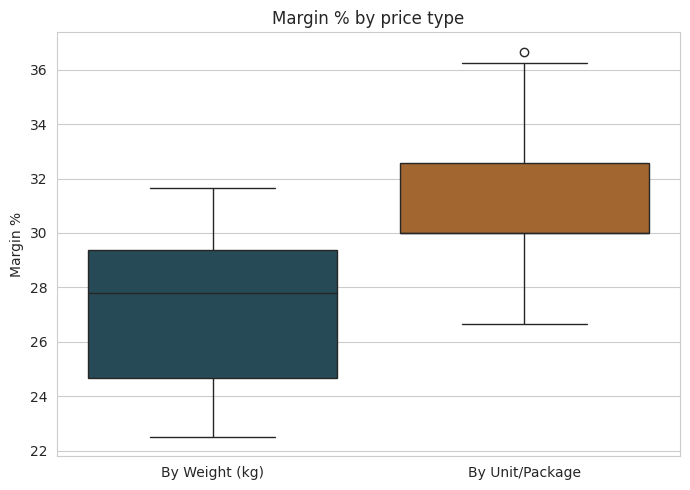

In [21]:
# Second test: is margin different for by-weight vs packaged products? (Welch t-test)
g_kg = prod.loc[prod["PriceType"]=="By Weight (kg)", "Margin_Pct"]*100
g_pk = prod.loc[prod["PriceType"]=="By Unit/Package", "Margin_Pct"]*100
t, p2 = stats.ttest_ind(g_kg, g_pk, equal_var=False)
print(f"By weight mean margin: {g_kg.mean():.1f}% (n={len(g_kg)})")
print(f"By unit/package mean margin: {g_pk.mean():.1f}% (n={len(g_pk)})")
print(f"Welch t = {t:.2f}, p = {p2:.4f}  ->  {'significant' if p2<0.05 else 'not significant'} at 95%")

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=prod, x="PriceType", y=prod["Margin_Pct"]*100, hue="PriceType",
            palette=[PALETTE[0],PALETTE[1]], legend=False, ax=ax)
ax.set_ylabel("Margin %"); ax.set_xlabel(""); ax.set_title("Margin % by price type")
plt.tight_layout(); plt.show()


## 10. Export analysis-ready data

Clean, flat tables ready to connect to a BI tool for dashboards. Six files are written to `analysis_export/`.

- **`analysis_products.csv`** — catalog enriched with margin, ABC class and current stock (grain: product).
- **`analysis_supply_links.csv`** — the supply-chain detail: **every product's primary AND backup supplier**,
  with purchase price, lead time, and the margin the business would keep if that particular link were used
  (grain: product-supplier link, 2 rows per product). This is what powers the "cost of resilience" analysis
  in Section 8 — it's the file to check when deciding whether a backup is worth keeping.
- **`analysis_purchases.csv`** — the raw purchase record for every batch bought over 2 years: quantity, unit
  cost, purchase date and expiry date, **before** it's known how the batch was sold (grain: batch, purchase
  side only).
- **`analysis_batches.csv`** — the same batches **joined with their outcome** (sold out / partial loss %,
  revenue, gross profit) — the full supply-based sales fact table (grain: batch, purchase + outcome).
- **`analysis_suppliers.csv`** — supplier scorecard with HHI contribution and dependency risk (grain: supplier, aggregated).
- **`analysis_monthly.csv`** — monthly revenue & waste trend (grain: month).
- **`analysis_inventory_optimization.csv`** — EOQ, reorder point and safety stock per product (grain:
  product; written later, in Section 12, once those figures are computed).

`analysis_purchases.csv` and `analysis_batches.csv` answer different questions: the first is purely
"what did we buy and when does it expire" (useful for a restocking/expiry-tracking view), the second adds
"how did it turn out" (useful for a revenue/waste view). `analysis_batches.csv` is the join of the two, so
most dashboards will reach for that one — but the raw purchase record is kept separate too, since that's
the one-to-one match to the Purchases sheet in the spreadsheet system.


In [22]:
import os
os.makedirs("analysis_export", exist_ok=True)

# products enriched
prod_out = prod[["ProductID","Product","Category","SaleUnit","PriceType","Essential","PeakSeason",
                 "CurrentStock","SalePrice_CLP","SalePrice_USD","PurchasePrice_CLP","Margin_CLP",
                 "Margin_Pct","Class","SupplierName","LeadTime_Days"]].copy()
prod_out.to_csv("analysis_export/analysis_products.csv", index=False, encoding="utf-8-sig")

# supply links (primary + backup), enriched with sale price & the margin that link would yield
links_out = links.merge(products[["ProductID","SalePrice_CLP","SalePrice_USD","Essential"]],
                         on="ProductID", how="left")
links_out["Margin_CLP_thisLink"] = links_out["SalePrice_CLP"] - links_out["PurchasePrice_CLP"]
links_out["Margin_Pct_thisLink"] = links_out["Margin_CLP_thisLink"] / links_out["SalePrice_CLP"]
links_out = links_out[["SupplyID","ProductID","Product","Category","Essential","SupplierRole","SupplierID",
                       "SupplierName","PurchasePrice_CLP","PurchasePrice_USD","PriceType","PurchaseUnit",
                       "LeadTime_Days","HasDelivery","SalePrice_CLP","SalePrice_USD",
                       "Margin_CLP_thisLink","Margin_Pct_thisLink"]]
links_out.to_csv("analysis_export/analysis_supply_links.csv", index=False, encoding="utf-8-sig")

# raw purchases (purchase side only, matches the Purchases sheet in the spreadsheet)
purchases_out = purchases.copy()
purchases_out["UnitCost_USD"] = (purchases_out["UnitCost_CLP"] / USD_RATE).round(2)
purchases_out = purchases_out[["BatchID","ProductID","Product","Category","SupplierRole","SupplierID",
                               "SupplierName","PurchaseDate","Quantity","Unit","UnitCost_CLP","UnitCost_USD",
                               "BatchCost_CLP","BatchCost_USD","ExpiryDate","ExpiryType","Season"]]
purchases_out.to_csv("analysis_export/analysis_purchases.csv", index=False, encoding="utf-8-sig")

# batch-level (the supply-based sales fact table: purchase + outcome)
batch_out = batches[["BatchID","ProductID","Product","Category","SupplierRole","SupplierName",
                     "PurchaseDate","ExpiryDate","Quantity","Unit","Status","QtySold","QtyWasted",
                     "WastedPct","Revenue_CLP","Revenue_USD","GrossProfit_CLP","GrossProfit_USD",
                     "Season","SeasonSH","YearMonth"]].copy()
batch_out.to_csv("analysis_export/analysis_batches.csv", index=False, encoding="utf-8-sig")

# supplier scorecard + HHI contribution
sc_out = scorecard.reset_index().copy()
sc_out["hhi_contribution"] = (sc_out["n_products"]/sc_out["n_products"].sum()*100)**2
sc_out["dependency_risk"] = np.select([sc_out["n_essential"]>=3, sc_out["n_essential"]>=1],
                                       ["High","Medium"], default="Low")
sc_out.to_csv("analysis_export/analysis_suppliers.csv", index=False, encoding="utf-8-sig")

# monthly trend
monthly.to_csv("analysis_export/analysis_monthly.csv", index=False, encoding="utf-8-sig")

print("Exported to analysis_export/:")
for f in sorted(os.listdir("analysis_export")): print("  -", f)
print(f"\nanalysis_supply_links.csv: {links_out.shape[0]} rows x {links_out.shape[1]} columns "
      f"({links_out['ProductID'].nunique()} products x 2 roles)")
print(f"analysis_purchases.csv: {purchases_out.shape[0]} rows x {purchases_out.shape[1]} columns (raw batches, purchase side only)")


Exported to analysis_export/:
  - analysis_batches.csv
  - analysis_monthly.csv
  - analysis_products.csv
  - analysis_purchases.csv
  - analysis_suppliers.csv
  - analysis_supply_links.csv

analysis_supply_links.csv: 256 rows x 18 columns (128 products x 2 roles)
analysis_purchases.csv: 3825 rows x 17 columns (raw batches, purchase side only)


In [23]:
purchases_out.head(4)


,BatchID,ProductID,Product,Category,SupplierRole,SupplierID,SupplierName,PurchaseDate,Quantity,Unit,UnitCost_CLP,UnitCost_USD,BatchCost_CLP,BatchCost_USD,ExpiryDate,ExpiryType,Season
0,B00001,P001,"Olives 120/140 (extra large), brined",Olives,Primary,S001,El Olivar Olives Ltd.,2023-07-09,16,kg,2950,3.16,47200,50.48,2023-08-23,Estimated,Winter
1,B00002,P001,"Olives 120/140 (extra large), brined",Olives,Primary,S001,El Olivar Olives Ltd.,2023-07-20,13,kg,2950,3.16,38350,41.02,2023-09-03,Estimated,Winter
2,B00003,P001,"Olives 120/140 (extra large), brined",Olives,Primary,S001,El Olivar Olives Ltd.,2023-07-29,13,kg,2950,3.16,38350,41.02,2023-09-12,Estimated,Winter
3,B00004,P001,"Olives 120/140 (extra large), brined",Olives,Primary,S001,El Olivar Olives Ltd.,2023-08-05,16,kg,2950,3.16,47200,50.48,2023-09-19,Estimated,Winter


### Priority of metrics to publish

| Priority | Metric | Why it matters | Best chart |
|---|---|---|---|
| 1 | Waste % by category & season | Directly justifies cold storage; where money leaks | Bar / seasonal bar |
| 2 | 2-year revenue & gross-profit trend | Shows the business trajectory | Line + bar combo |
| 3 | Backup coverage & supplier HHI | Supply-chain resilience at a glance | Indicator + bar |
| 4 | ABC (revenue Pareto) | Focus attention on the ~20% driving 80% | Pareto |
| 5 | Restock urgency (essential + low stock) | Prevents stockouts of key lines | Traffic-light table |

Together these tell the whole story: what sells, what it costs, what gets wasted, and what to watch — the
foundation for a BI dashboard built on the six exported files.


## 11. Business case: freezer ROI

The Process Memoir states the chest freezer was bought to cut spoilage in **Olives** and **Grains**
(cooked mote) — the two categories most affected by summer heat. This section connects that narrative to
the actual waste data: how much is really being lost in those two categories, and how long the freezer
takes to pay for itself.

**Assumption (explicit):** freezing does not eliminate spoilage entirely — some loss happens before a
batch would even reach the freezer, and the freezer only helps with the *heat-driven* excess, not the
baseline spoilage that would happen anyway. So instead of one fake-precise number, this section shows a
**sensitivity range**: what the payback looks like if the freezer prevents 50%, 65% or 80% of the wasted
value in these two categories.


In [24]:
FREEZER_TARGET_CATEGORIES = ["Olives", "Grains"]
FREEZER_COST_USD_LOW, FREEZER_COST_USD_HIGH = 270, 340  # from the Process Memoir investment table

target = batches[batches["Category"].isin(FREEZER_TARGET_CATEGORIES)]
wasted_value_usd = (target["QtyWasted"] * target.merge(
    products[["ProductID","SalePrice_USD"]], on="ProductID")["SalePrice_USD"].values).sum()
n_years = (batches["PurchaseDate"].max() - batches["PurchaseDate"].min()).days / 365.25
annual_wasted_value_usd = wasted_value_usd / n_years

print(f"Observation window: {n_years:.1f} years")
print(f"Total wasted value (Olives + Grains, 2Y): US$ {wasted_value_usd:,.0f}")
print(f"Annualized wasted value (Olives + Grains): US$ {annual_wasted_value_usd:,.0f}/year")


Observation window: 2.0 years
Total wasted value (Olives + Grains, 2Y): US$ 6,911
Annualized wasted value (Olives + Grains): US$ 3,458/year


,Scenario,PreventedFraction,AnnualSavings_USD,Payback_Months_LowCost,Payback_Months_HighCost
0,Conservative (50% prevented),0.5,1729.0,1.9,2.4
1,Base case (65% prevented),0.6,2247.7,1.4,1.8
2,Optimistic (80% prevented),0.8,2766.5,1.2,1.5


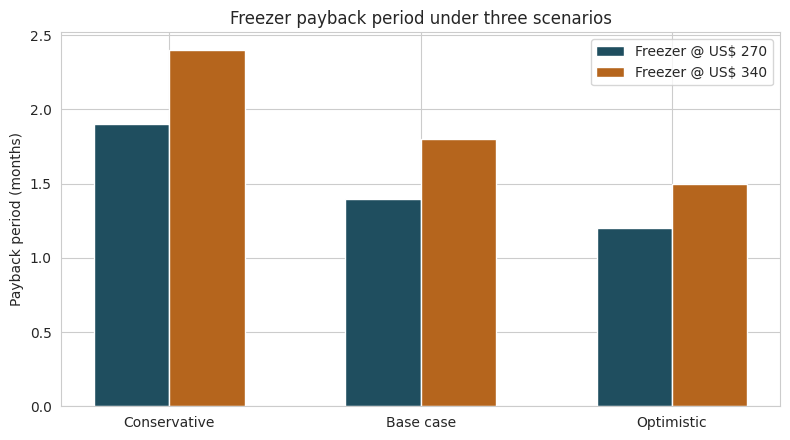


Base case: the freezer pays for itself in 1-2 months, then keeps saving roughly US$ 2,248/year after that.


In [25]:
scenarios = pd.DataFrame({
    "Scenario": ["Conservative (50% prevented)", "Base case (65% prevented)", "Optimistic (80% prevented)"],
    "PreventedFraction": [0.50, 0.65, 0.80],
})
scenarios["AnnualSavings_USD"] = scenarios["PreventedFraction"] * annual_wasted_value_usd
scenarios["Payback_Months_LowCost"] = (FREEZER_COST_USD_LOW / scenarios["AnnualSavings_USD"]) * 12
scenarios["Payback_Months_HighCost"] = (FREEZER_COST_USD_HIGH / scenarios["AnnualSavings_USD"]) * 12
scenarios = scenarios.round(1)
display(scenarios)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(scenarios))
ax.bar(x-0.15, scenarios["Payback_Months_LowCost"], width=0.3, label=f"Freezer @ US$ {FREEZER_COST_USD_LOW}", color=PALETTE[0])
ax.bar(x+0.15, scenarios["Payback_Months_HighCost"], width=0.3, label=f"Freezer @ US$ {FREEZER_COST_USD_HIGH}", color=PALETTE[1])
ax.set_xticks(x); ax.set_xticklabels(["Conservative","Base case","Optimistic"])
ax.set_ylabel("Payback period (months)"); ax.set_title("Freezer payback period under three scenarios")
ax.legend()
plt.tight_layout(); plt.show()

base = scenarios.iloc[1]
print(f"\nBase case: the freezer pays for itself in {base['Payback_Months_LowCost']:.0f}-{base['Payback_Months_HighCost']:.0f} months, "
      f"then keeps saving roughly US$ {base['AnnualSavings_USD']:,.0f}/year after that.")


Even in the conservative scenario, payback lands well inside a single year — the freezer purchase is not
just a good operational call, it is a **quick-return investment**, which is exactly the kind of statement
a business case needs and the kind of number this project was missing before.


## 12. Inventory optimization: EOQ, reorder point & safety stock

This is the calculation the project's title ("a well-prepared inventory") promised but never actually
delivered. Two kinds of inputs go into it:

- **Empirical (from real 2-year purchase history):** average daily demand and its variability per
  product, and each product's lead time from its primary supplier — both already in the data, no guessing.
- **Assumed (stated explicitly, adjust if better numbers exist):** a 25%/year holding-cost rate on the
  purchase cost, and a flat ~US$3 ordering cost per purchase order (time/effort of placing an order at
  this scale). These two are the standard textbook defaults when a business doesn't track exact
  warehousing or admin cost — swap them for real figures if the business measures them later.


In [26]:
HOLDING_COST_RATE = 0.25   # % of purchase cost held per year — assumption
ORDER_COST_USD = 3.0       # flat cost per purchase order — assumption
SERVICE_LEVEL_Z = 1.645    # ~95% service level

obs_days = (batches["PurchaseDate"].max() - batches["PurchaseDate"].min()).days

demand_stats = batches.groupby("ProductID").agg(
    total_qty=("Quantity","sum"),
    n_batches=("Quantity","count"),
).reset_index()
demand_stats["avg_daily_demand"] = demand_stats["total_qty"] / obs_days

# variability of demand: std of quantity per purchase, scaled to a daily basis via batch frequency
batch_std = batches.groupby("ProductID")["Quantity"].std().fillna(0).rename("qty_std").reset_index()
demand_stats = demand_stats.merge(batch_std, on="ProductID")
demand_stats["avg_days_between_orders"] = obs_days / demand_stats["n_batches"]
# daily demand std, approximated from batch-to-batch variability and order frequency
demand_stats["daily_demand_std"] = demand_stats["qty_std"] / np.sqrt(demand_stats["avg_days_between_orders"])

inv = demand_stats.merge(prod[["ProductID","Product","Category","Essential","PurchasePrice_CLP","SalePrice_USD"]],
                         on="ProductID").merge(
    primary[["ProductID","LeadTime_Days"]].rename(columns={"LeadTime_Days":"lead_time_days"}), on="ProductID")
inv["lead_time_days"] = inv["lead_time_days"].fillna(inv["lead_time_days"].median())
inv["purchase_cost_usd"] = inv["PurchasePrice_CLP"] / USD_RATE

inv["annual_demand"] = inv["avg_daily_demand"] * 365
inv["holding_cost_usd"] = HOLDING_COST_RATE * inv["purchase_cost_usd"]
inv["EOQ"] = np.sqrt(2 * inv["annual_demand"] * ORDER_COST_USD / inv["holding_cost_usd"].replace(0, np.nan))
inv["safety_stock"] = SERVICE_LEVEL_Z * inv["daily_demand_std"] * np.sqrt(inv["lead_time_days"])
inv["reorder_point"] = inv["avg_daily_demand"] * inv["lead_time_days"] + inv["safety_stock"]

inv_out = inv[["ProductID","Product","Category","Essential","avg_daily_demand","lead_time_days",
               "EOQ","safety_stock","reorder_point"]].round(2)
print("Sample (essential products first):")
display(inv_out.sort_values("Essential", ascending=False).head(10))
n_zero_lead = (inv_out["lead_time_days"]==0).sum()
print(f"\nNote: {n_zero_lead} products show reorder_point = 0 because their primary supplier's lead time "
      f"is 0 days (same-day fulfillment) — with instant replenishment, no buffer is mathematically needed. "
      f"That's an expected edge case, not a data error.")


Sample (essential products first):


,ProductID,Product,Category,Essential,avg_daily_demand,lead_time_days,EOQ,safety_stock,reorder_point
0,P001,"Olives 120/140 (extra large), brined",Olives,Yes,3.10,3,92.82,12.84,22.15
11,P012,Cooked mote (hominy wheat),Grains,Yes,5.50,0,197.87,0.00,0.00
40,P041,"Multiflora honey, bottle 500g",Honey,Yes,0.42,0,33.07,0.00,0.00
94,P095,Dried prunes (with pit),Dried Fruit,Yes,0.51,1,34.99,2.16,2.67
45,P046,Roasted salted peanuts,Peanuts,Yes,1.07,1,42.90,1.13,2.19
30,P031,"Ground cumin, bag 100g",Seasonings,Yes,0.90,2,83.66,1.77,3.57
29,P030,"All-purpose seasoning, bag 100g",Seasonings,Yes,0.83,0,80.47,0.00,0.00
91,P092,Golden raisins,Raisins,Yes,0.53,1,28.45,2.41,2.93
21,P022,"Bottled chili sauce, bottle 200ml",Chili,Yes,0.68,3,64.01,1.65,3.68
20,P021,"Ground golden chili (aji de color), bag 100g",Chili,Yes,1.56,1,93.88,1.91,3.47



Note: 24 products show reorder_point = 0 because their primary supplier's lead time is 0 days (same-day fulfillment) — with instant replenishment, no buffer is mathematically needed. That's an expected edge case, not a data error.


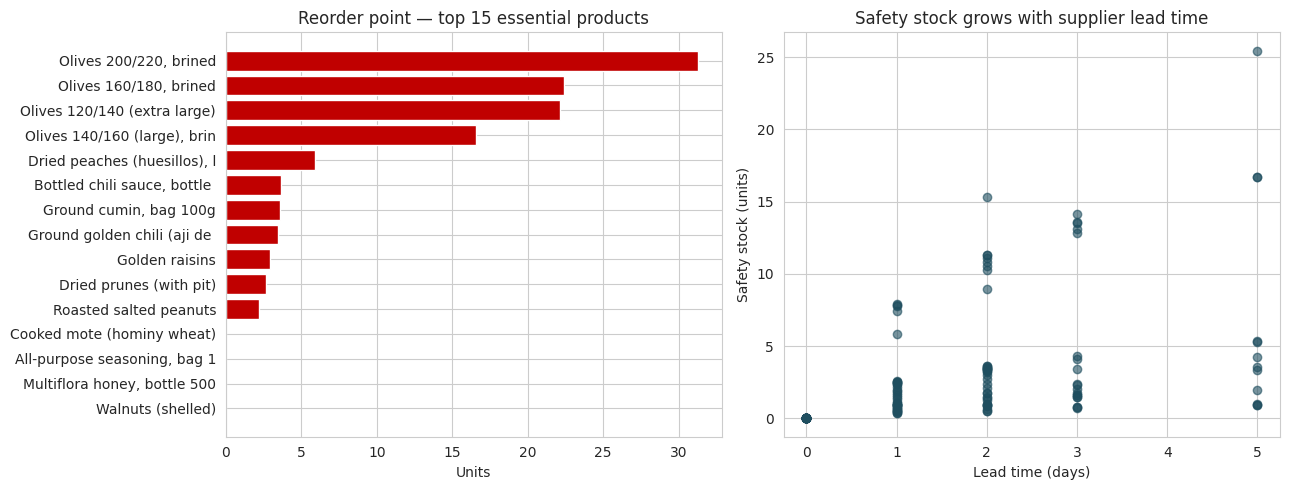

As expected, safety stock scales with lead time (sqrt relationship) — products from slower
suppliers need a bigger buffer, which is exactly why the backup-supplier lead times from
Section 8 matter for this calculation too.


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ess_inv = inv_out[inv_out["Essential"]=="Yes"].sort_values("reorder_point", ascending=False).head(15)
axes[0].barh(ess_inv["Product"].str.slice(0,28), ess_inv["reorder_point"], color=PALETTE[4])
axes[0].invert_yaxis(); axes[0].set_title("Reorder point — top 15 essential products"); axes[0].set_xlabel("Units")

axes[1].scatter(inv_out["lead_time_days"], inv_out["safety_stock"], alpha=0.6, color=PALETTE[0])
axes[1].set_xlabel("Lead time (days)"); axes[1].set_ylabel("Safety stock (units)")
axes[1].set_title("Safety stock grows with supplier lead time")
plt.tight_layout(); plt.show()
print("As expected, safety stock scales with lead time (sqrt relationship) — products from slower")
print("suppliers need a bigger buffer, which is exactly why the backup-supplier lead times from")
print("Section 8 matter for this calculation too.")


**How to use this in practice:** when `CurrentStock` drops toward the `reorder_point` for a given product,
that is the trigger to place an order of about `EOQ` units — not an arbitrary refill. This turns the
Excel's Red/Yellow/Green stock flag into an actual number to act on.


In [28]:
inv_out.to_csv("analysis_export/analysis_inventory_optimization.csv", index=False, encoding="utf-8-sig")
print(f"Exported analysis_export/analysis_inventory_optimization.csv ({inv_out.shape[0]} products)")


Exported analysis_export/analysis_inventory_optimization.csv (128 products)


## 13. Demand forecasting

Everything so far has been diagnostic (what happened). With two full years of purchase history we have
exactly two seasonal cycles — enough for a first, honest forecasting pass. We use **Holt-Winters triple
exponential smoothing** (trend + yearly seasonality) on monthly purchased quantity, validated with a
**walk-forward backtest**: forecast one month ahead, compare to what was actually bought, roll forward,
repeat — the same discipline used in production forecasting, just simplified.


Series length: 24 months


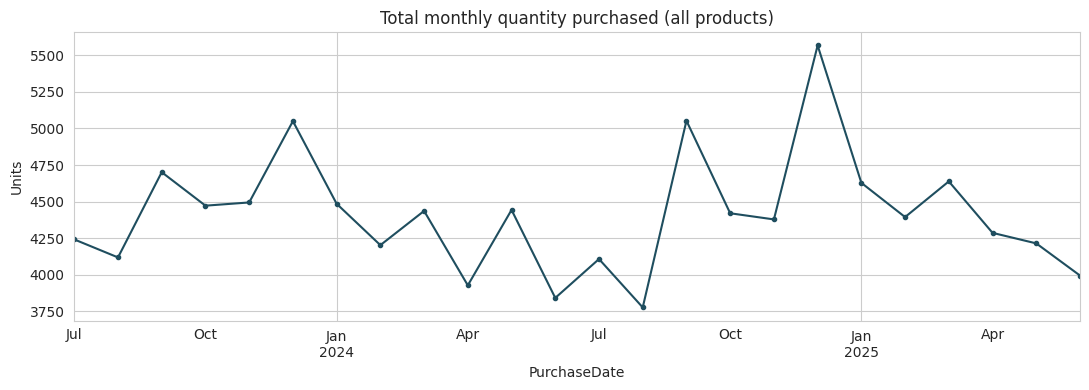

In [29]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

monthly_qty = batches.groupby(batches["PurchaseDate"].dt.to_period("M"))["Quantity"].sum()
monthly_qty.index = monthly_qty.index.to_timestamp()
print(f"Series length: {len(monthly_qty)} months")
monthly_qty.plot(figsize=(11,4), color=PALETTE[0], marker="o", markersize=3, title="Total monthly quantity purchased (all products)")
plt.ylabel("Units"); plt.tight_layout(); plt.show()


In [30]:
# Walk-forward backtest over the last 6 months
def backtest_hw(series, test_months=6, seasonal_periods=12):
    errors = []
    for i in range(len(series)-test_months, len(series)):
        train = series.iloc[:i]
        actual = series.iloc[i]
        try:
            model = ExponentialSmoothing(train, trend="add", seasonal="add",
                                          seasonal_periods=seasonal_periods).fit()
            pred = model.forecast(1).iloc[0]
        except Exception:
            pred = train.iloc[-seasonal_periods:].mean()  # seasonal-naive fallback
        errors.append({"month": series.index[i], "actual": actual, "forecast": pred,
                        "abs_pct_error": abs(actual-pred)/actual*100})
    return pd.DataFrame(errors)

bt = backtest_hw(monthly_qty)
display(bt.round(1))
print(f"\nBacktest MAPE (last 6 months, 1-month-ahead): {bt['abs_pct_error'].mean():.1f}%")


,month,actual,forecast,abs_pct_error
0,2025-01-01,4628,4386.3,5.2
1,2025-02-01,4394,4398.2,0.1
2,2025-03-01,4638,4414.2,4.8
3,2025-04-01,4286,4431.1,3.4
4,2025-05-01,4214,4461.0,5.9
5,2025-06-01,3994,4441.9,11.2



Backtest MAPE (last 6 months, 1-month-ahead): 5.1%


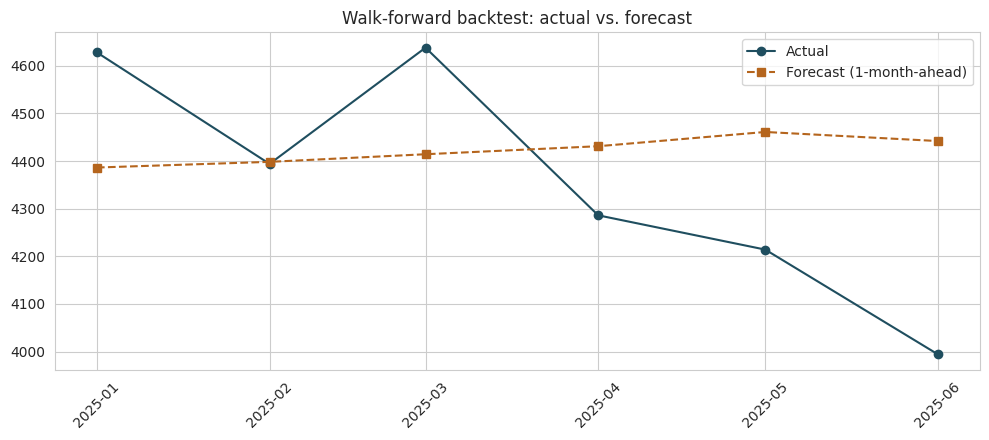

In [31]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(bt["month"], bt["actual"], marker="o", label="Actual", color=PALETTE[0])
ax.plot(bt["month"], bt["forecast"], marker="s", label="Forecast (1-month-ahead)", color=PALETTE[1], linestyle="--")
ax.set_title("Walk-forward backtest: actual vs. forecast"); ax.legend()
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


Next 3 months forecast (total units to purchase, all products):
2025-07-01    4305.0
2025-08-01    4078.0
2025-09-01    5008.0
Freq: MS


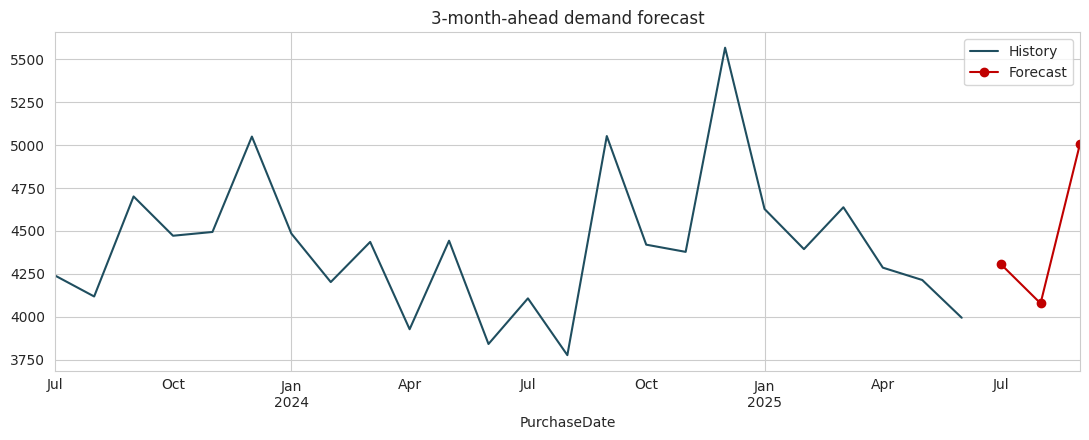

In [32]:
# Final model on the full series, forecast next 3 months
final_model = ExponentialSmoothing(monthly_qty, trend="add", seasonal="add", seasonal_periods=12).fit()
future = final_model.forecast(3)
print("Next 3 months forecast (total units to purchase, all products):")
print(future.round(0).to_string())

fig, ax = plt.subplots(figsize=(11, 4.5))
monthly_qty.plot(ax=ax, color=PALETTE[0], label="History")
future.plot(ax=ax, color=PALETTE[4], marker="o", label="Forecast")
ax.set_title("3-month-ahead demand forecast"); ax.legend()
plt.tight_layout(); plt.show()


A ~2-year history is short for seasonal forecasting (ideally you'd want 3+ cycles), so this forecast
should be treated as a first pass to refine as more months come in — but the backtest MAPE gives an honest
sense of how much to trust it today, rather than presenting the forecast as more certain than it is.
